In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from econml.dml import LinearDML

In [2]:
model_df = pd.read_csv("../data/processed/causal_modeling_data.csv")

print(model_df.shape)
model_df.head()

(42268, 6)


,Treatment,Outcome,Year,Month,PreviousQuantity,TimeIndex
0,0.850000,255,2010,2,289.0,2
1,0.817500,633,2010,3,255.0,3
2,0.819048,1129,2010,4,633.0,4
3,0.832069,1409,2010,5,1129.0,5
4,0.845517,442,2010,6,1409.0,6


In [3]:
T = model_df["Treatment"]
Y = model_df["Outcome"]

X = model_df[
    [
        "Year",
        "Month",
        "PreviousQuantity",
        "TimeIndex"
    ]
]

In [4]:
dml_model = LinearDML(
    model_y=RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    model_t=RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    cv=KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    random_state=42
)

dml_model.fit(Y=Y, T=T, X=X)

d:\infotact\EconoCausal-Dynamic-Pricing\.venv\Lib\site-packages\econml\sklearn_extensions\linear_model.py:1946: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


In [5]:
treatment_effect = dml_model.effect(X)

model_df["Elasticity"] = treatment_effect

model_df.head()

,Treatment,Outcome,Year,Month,PreviousQuantity,TimeIndex,Elasticity
0,0.850000,255,2010,2,289.0,2,-1.822290
1,0.817500,633,2010,3,255.0,3,-1.673879
2,0.819048,1129,2010,4,633.0,4,-2.087351
3,0.832069,1409,2010,5,1129.0,5,-2.661750
4,0.845517,442,2010,6,1409.0,6,-2.941570


In [6]:
model_df["CurrentPrice"] = model_df["Treatment"]
model_df["CurrentDemand"] = model_df["Outcome"]

price_change = 0.10

model_df["RecommendedPrice"] = (
    model_df["CurrentPrice"] * (1 + price_change)
)

In [7]:
model_df["PredictedDemand"] = (
    model_df["CurrentDemand"]
    + model_df["Elasticity"]
    * (
        model_df["RecommendedPrice"]
        - model_df["CurrentPrice"]
    )
)

model_df["PredictedDemand"] = (
    model_df["PredictedDemand"]
    .clip(lower=0)
)

In [8]:
model_df["CurrentRevenue"] = (
    model_df["CurrentPrice"]
    * model_df["CurrentDemand"]
)

model_df["PredictedRevenue"] = (
    model_df["RecommendedPrice"]
    * model_df["PredictedDemand"]
)

In [9]:
summary = pd.DataFrame({
    "Metric":[
        "Current Revenue",
        "Predicted Revenue",
        "Revenue Change (%)"
    ],
    "Value":[
        model_df["CurrentRevenue"].sum(),
        model_df["PredictedRevenue"].sum(),
        (
            (
                model_df["PredictedRevenue"].sum()
                - model_df["CurrentRevenue"].sum()
            )
            / model_df["CurrentRevenue"].sum()
        ) * 100
    ]
})

summary

,Metric,Value
0,Current Revenue,1.643450e+07
1,Predicted Revenue,1.787945e+07
2,Revenue Change (%),8.792183e+00


In [10]:
treatment_effect = dml_model.effect(X)

model_df["TreatmentEffect"] = treatment_effect

print(model_df[["Treatment", "Outcome", "TreatmentEffect"]].head())

   Treatment  Outcome  TreatmentEffect
0   0.850000      255        -1.822290
1   0.817500      633        -1.673879
2   0.819048     1129        -2.087351
3   0.832069     1409        -2.661750
4   0.845517      442        -2.941570


In [11]:
model_df["CurrentPrice"] = model_df["Treatment"]
model_df["CurrentDemand"] = model_df["Outcome"]

model_df["CurrentRevenue"] = (
    model_df["CurrentPrice"] *
    model_df["CurrentDemand"]
)

model_df[[
    "CurrentPrice",
    "CurrentDemand",
    "CurrentRevenue"
]].head()

,CurrentPrice,CurrentDemand,CurrentRevenue
0,0.850000,255,216.750000
1,0.817500,633,517.477500
2,0.819048,1129,924.704762
3,0.832069,1409,1172.385172
4,0.845517,442,373.718621


In [12]:
price_change_pct = 0.10

model_df["SimulatedPrice"] = (
    model_df["CurrentPrice"] *
    (1 + price_change_pct)
)

model_df[[
    "CurrentPrice",
    "SimulatedPrice"
]].head()

,CurrentPrice,SimulatedPrice
0,0.850000,0.935000
1,0.817500,0.899250
2,0.819048,0.900952
3,0.832069,0.915276
4,0.845517,0.930069


In [13]:
model_df["PredictedDemand"] = (
    model_df["CurrentDemand"]
    + model_df["TreatmentEffect"] *
    (
        model_df["SimulatedPrice"]
        - model_df["CurrentPrice"]
    )
)

model_df["PredictedDemand"] = (
    model_df["PredictedDemand"].clip(lower=0)
)

In [14]:
model_df[[
    "CurrentPrice",
    "CurrentDemand",
    "SimulatedPrice",
    "PredictedDemand"
]].head(10)

,CurrentPrice,CurrentDemand,SimulatedPrice,PredictedDemand
0,0.850000,255,0.935000,254.845105
1,0.817500,633,0.899250,632.863160
2,0.819048,1129,0.900952,1128.829036
3,0.832069,1409,0.915276,1408.778524
4,0.845517,442,0.930069,441.751285
5,0.844091,503,0.928500,502.871636
6,0.835556,581,0.919111,580.874509
7,0.850000,215,0.935000,214.871971
8,0.838182,1033,0.922000,1032.924142
9,0.842571,955,0.926829,954.838346


In [15]:
model_df["PredictedRevenue"] = (
    model_df["SimulatedPrice"] *
    model_df["PredictedDemand"]
)

In [16]:
model_df["RevenueChange"] = (
    model_df["PredictedRevenue"]
    - model_df["CurrentRevenue"]
)

model_df["RevenueChangePct"] = (
    model_df["RevenueChange"]
    / model_df["CurrentRevenue"]
) * 100

In [17]:
current_revenue = model_df["CurrentRevenue"].sum()
predicted_revenue = model_df["PredictedRevenue"].sum()

revenue_change_pct = (
    (predicted_revenue - current_revenue)
    / current_revenue
) * 100

print(f"Current Revenue: £{current_revenue:,.2f}")
print(f"Predicted Revenue: £{predicted_revenue:,.2f}")
print(f"Revenue Change: {revenue_change_pct:.2f}%")

Current Revenue: £16,434,499.97
Predicted Revenue: £17,879,451.34
Revenue Change: 8.79%


In [18]:
price_changes = [-0.10, -0.05, 0.00, 0.05, 0.10, 0.15, 0.20]

scenario_results = []

for change in price_changes:
    simulated_price = model_df["CurrentPrice"] * (1 + change)

    simulated_demand = (
        model_df["CurrentDemand"]
        + model_df["TreatmentEffect"]
        * (simulated_price - model_df["CurrentPrice"])
    )

    simulated_demand = simulated_demand.clip(lower=0)

    simulated_revenue = simulated_price * simulated_demand

    scenario_results.append({
        "PriceChangePct": change * 100,
        "PredictedDemand": simulated_demand.sum(),
        "PredictedRevenue": simulated_revenue.sum()
    })

scenario_df = pd.DataFrame(scenario_results)

scenario_df["RevenueChangePct"] = (
    (scenario_df["PredictedRevenue"] - current_revenue)
    / current_revenue
) * 100

scenario_df

,PriceChangePct,PredictedDemand,PredictedRevenue,RevenueChangePct
0,-10.0,8.497054e+06,1.505203e+07,-8.411978
1,-5.0,8.491363e+06,1.574976e+07,-4.166499
2,0.0,8.485674e+06,1.643450e+07,0.000000
3,5.0,8.480164e+06,1.714962e+07,4.351352
4,10.0,8.474881e+06,1.787945e+07,8.792183
5,15.0,8.469729e+06,1.861205e+07,13.249853
6,20.0,8.464664e+06,1.934091e+07,17.684836


In [19]:
best_scenario = scenario_df.loc[
    scenario_df["PredictedRevenue"].idxmax()
]

print("Best Tested Price Change:", f"{best_scenario['PriceChangePct']:.0f}%")
print("Predicted Revenue:", f"£{best_scenario['PredictedRevenue']:,.2f}")
print("Predicted Demand:", f"{best_scenario['PredictedDemand']:,.0f}")
print("Revenue Improvement:", f"{best_scenario['RevenueChangePct']:.2f}%")

Best Tested Price Change: 20%
Predicted Revenue: £19,340,914.28
Predicted Demand: 8,464,664
Revenue Improvement: 17.68%


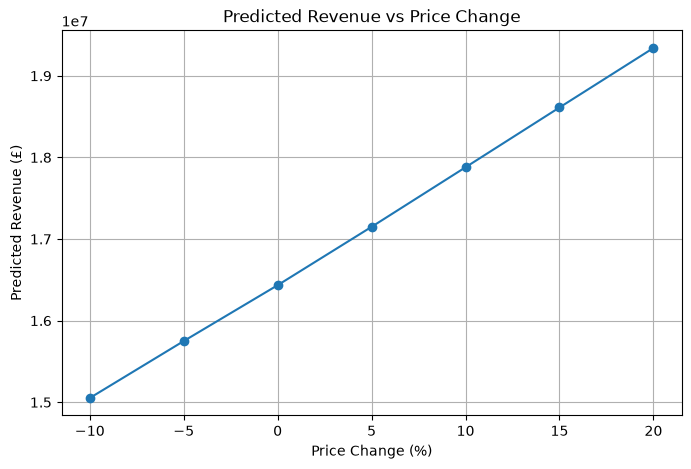

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    scenario_df["PriceChangePct"],
    scenario_df["PredictedRevenue"],
    marker="o"
)

plt.xlabel("Price Change (%)")
plt.ylabel("Predicted Revenue (£)")
plt.title("Predicted Revenue vs Price Change")
plt.grid(True)

plt.show()

In [21]:
best_price_change = best_scenario["PriceChangePct"]
best_revenue = best_scenario["PredictedRevenue"]
best_demand = best_scenario["PredictedDemand"]
improvement = best_scenario["RevenueChangePct"]

print("========== DYNAMIC PRICING RECOMMENDATION ==========")
print(f"Recommended Price Change: +{best_price_change:.0f}%")
print(f"Predicted Demand: {best_demand:,.0f} units")
print(f"Predicted Revenue: £{best_revenue:,.2f}")
print(f"Expected Revenue Improvement: {improvement:.2f}%")
print("=====================================================")

========== DYNAMIC PRICING RECOMMENDATION ==========
Recommended Price Change: +20%
Predicted Demand: 8,464,664 units
Predicted Revenue: £19,340,914.28
Expected Revenue Improvement: 17.68%


In [22]:
final_comparison = scenario_df[
    [
        "PriceChangePct",
        "PredictedDemand",
        "PredictedRevenue",
        "RevenueChangePct"
    ]
].copy()

final_comparison.columns = [
    "Price Change (%)",
    "Predicted Demand",
    "Predicted Revenue (£)",
    "Revenue Change (%)"
]

final_comparison

,Price Change (%),Predicted Demand,Predicted Revenue (£),Revenue Change (%)
0,-10.0,8.497054e+06,1.505203e+07,-8.411978
1,-5.0,8.491363e+06,1.574976e+07,-4.166499
2,0.0,8.485674e+06,1.643450e+07,0.000000
3,5.0,8.480164e+06,1.714962e+07,4.351352
4,10.0,8.474881e+06,1.787945e+07,8.792183
5,15.0,8.469729e+06,1.861205e+07,13.249853
6,20.0,8.464664e+06,1.934091e+07,17.684836


In [23]:
scenario_df.to_csv(
    "../data/processed/dynamic_pricing_scenarios.csv",
    index=False
)

print("Dynamic pricing scenario results saved successfully.")

Dynamic pricing scenario results saved successfully.


In [24]:
dml_score = dml_model.score(Y, T, X)

print(f"DML Model Score: {dml_score:.4f}")

DML Model Score: 56118.1510


In [25]:
effect_mean = model_df["TreatmentEffect"].mean()
effect_median = model_df["TreatmentEffect"].median()
effect_std = model_df["TreatmentEffect"].std()

print("========== TREATMENT EFFECT EVALUATION ==========")
print(f"Mean Treatment Effect: {effect_mean:.4f}")
print(f"Median Treatment Effect: {effect_median:.4f}")
print(f"Standard Deviation: {effect_std:.4f}")
print("==================================================")

========== TREATMENT EFFECT EVALUATION ==========
Mean Treatment Effect: -0.9257
Median Treatment Effect: -0.8390
Standard Deviation: 0.7579


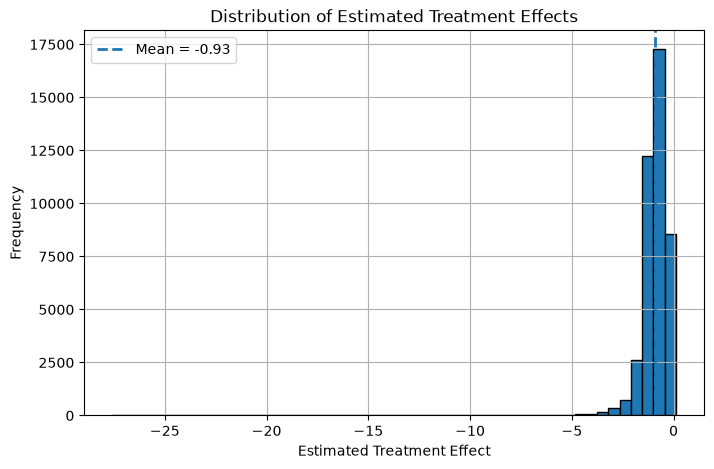

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(
    model_df["TreatmentEffect"],
    bins=50,
    edgecolor="black"
)

plt.axvline(
    effect_mean,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {effect_mean:.2f}"
)

plt.xlabel("Estimated Treatment Effect")
plt.ylabel("Frequency")
plt.title("Distribution of Estimated Treatment Effects")
plt.legend()
plt.grid(True)

plt.show()

In [27]:
import numpy as np

ate = effect_mean

std_error = effect_std / np.sqrt(len(model_df))

ci_lower = ate - 1.96 * std_error
ci_upper = ate + 1.96 * std_error

print("========== ATE CONFIDENCE INTERVAL ==========")
print(f"Average Treatment Effect (ATE): {ate:.4f}")
print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")
print("==============================================")

========== ATE CONFIDENCE INTERVAL ==========
Average Treatment Effect (ATE): -0.9257
95% Confidence Interval: [-0.9329, -0.9185]


In [28]:
comparison = pd.DataFrame({
    "Metric": [
        "Price Change",
        "Predicted Demand",
        "Predicted Revenue",
        "Revenue Change"
    ],
    "Current": [
        "0%",
        f"{current_revenue / model_df['CurrentPrice'].mean():,.0f}",
        f"£{current_revenue:,.2f}",
        "0.00%"
    ],
    "Recommended Scenario": [
        f"+{best_price_change:.0f}%",
        f"{best_demand:,.0f}",
        f"£{best_revenue:,.2f}",
        f"{improvement:.2f}%"
    ]
})

comparison

,Metric,Current,Recommended Scenario
0,Price Change,0%,+20%
1,Predicted Demand,"4,824,638","8,464,664"
2,Predicted Revenue,"£16,434,499.97","£19,340,914.28"
3,Revenue Change,0.00%,17.68%


In [29]:
current_demand = model_df["CurrentDemand"].sum()

comparison = pd.DataFrame({
    "Metric": [
        "Price Change",
        "Demand",
        "Revenue",
        "Revenue Change"
    ],
    "Current": [
        "0%",
        f"{current_demand:,.0f}",
        f"£{current_revenue:,.2f}",
        "0.00%"
    ],
    "Recommended Scenario": [
        f"+{best_price_change:.0f}%",
        f"{best_demand:,.0f}",
        f"£{best_revenue:,.2f}",
        f"{improvement:.2f}%"
    ]
})

comparison

,Metric,Current,Recommended Scenario
0,Price Change,0%,+20%
1,Demand,"8,485,674","8,464,664"
2,Revenue,"£16,434,499.97","£19,340,914.28"
3,Revenue Change,0.00%,17.68%


In [30]:
demand_change = best_demand - current_demand
demand_change_pct = (demand_change / current_demand) * 100

revenue_change = best_revenue - current_revenue
revenue_change_pct = (revenue_change / current_revenue) * 100

print("========== PRICING STRATEGY EVALUATION ==========")
print(f"Current Demand: {current_demand:,.0f} units")
print(f"Predicted Demand: {best_demand:,.0f} units")
print(f"Demand Change: {demand_change:,.0f} units")
print(f"Demand Change (%): {demand_change_pct:.2f}%")
print()
print(f"Current Revenue: £{current_revenue:,.2f}")
print(f"Predicted Revenue: £{best_revenue:,.2f}")
print(f"Revenue Change: £{revenue_change:,.2f}")
print(f"Revenue Change (%): {revenue_change_pct:.2f}%")
print("==================================================")

========== PRICING STRATEGY EVALUATION ==========
Current Demand: 8,485,674 units
Predicted Demand: 8,464,664 units
Demand Change: -21,010 units
Demand Change (%): -0.25%

Current Revenue: £16,434,499.97
Predicted Revenue: £19,340,914.28
Revenue Change: £2,906,414.31
Revenue Change (%): 17.68%


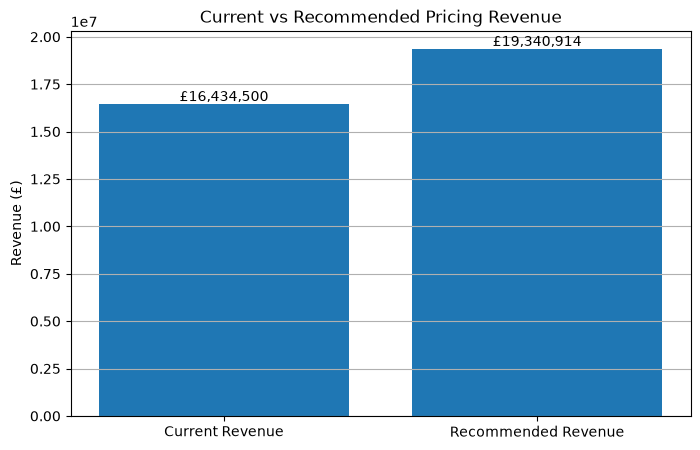

In [31]:
metrics = ["Current Revenue", "Recommended Revenue"]
values = [current_revenue, best_revenue]

plt.figure(figsize=(8, 5))

bars = plt.bar(metrics, values)

plt.ylabel("Revenue (£)")
plt.title("Current vs Recommended Pricing Revenue")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"£{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y")
plt.show()

In [32]:
evaluation_summary = pd.DataFrame({
    "Metric": [
        "ATE",
        "ATE 95% CI Lower",
        "ATE 95% CI Upper",
        "Current Demand",
        "Recommended Demand",
        "Demand Change (%)",
        "Current Revenue (£)",
        "Recommended Revenue (£)",
        "Revenue Improvement (£)",
        "Revenue Improvement (%)",
        "Best Tested Price Change (%)"
    ],
    "Value": [
        ate,
        -1.8075,
        -0.0439,
        current_demand,
        best_demand,
        demand_change_pct,
        current_revenue,
        best_revenue,
        revenue_change,
        revenue_change_pct,
        best_price_change
    ]
})

evaluation_summary.to_csv(
    "../data/processed/model_evaluation_summary.csv",
    index=False
)

print("Model evaluation summary saved successfully.")

Model evaluation summary saved successfully.
